<a href="https://colab.research.google.com/github/joshyajith863/Deep-learning-dl-lab/blob/main/Exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_760/2661970709.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

Epoch 1/10



/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0115 - val_loss: 5.3364e-04
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 3.2348e-04 - val_loss: 3.5335e-04
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.7085e-04 - val_loss: 2.0948e-04
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 2.4810e-04 - val_loss: 1.8481e-04
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.3574e-04 - val_loss: 2.0821e-04
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.2726e-04 - val_loss: 1.6939e-04
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.1242e-04 - val_loss: 2.0672e-04
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.0636e-04 - val_loss: 1.7962e-04
Epoch 9/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.9619e-04 - val_loss: 2.1075e-04
Epoch 10/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 1.9002e-04 - val_loss: 1.4785e-04
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


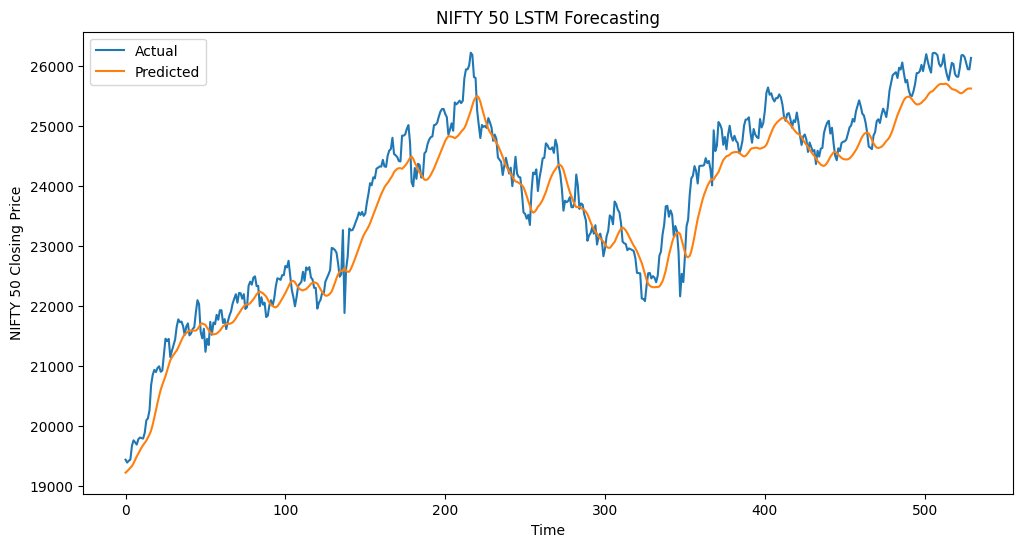

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Next Day NIFTY 50: 25630.824


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# 1. Download NIFTY 50 data
data = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01"
)

# 2. Select closing price
close_data = data[['Close']].values


# 3. Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_data)


# 4. Create sequences
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


# 5. Train-test split
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


# 6. Reshape for LSTM
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)


# 7. Build LSTM model
model = Sequential([
    LSTM(
        50,
        input_shape=(60, 1)
    ),
    Dense(1)
])


# 8. Compile
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)


# 9. Train
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


# 10. Prediction
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)


# 11. Plot results
plt.figure(figsize=(12, 6))

plt.plot(
    actual,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.title('NIFTY 50 LSTM Forecasting')
plt.xlabel('Time')
plt.ylabel('NIFTY 50 Closing Price')
plt.legend()
plt.show()


# 12. Predict next day
last_60_days = scaled_data[-60:]

X_future = last_60_days.reshape(
    1, 60, 1
)

prediction = model.predict(X_future)

prediction = scaler.inverse_transform(
    prediction
)

print(
    "Predicted Next Day NIFTY 50:",
    prediction[0][0]
)
